In [2]:

import numpy as np
import matplotlib.pyplot as plt
import h5py
import networkx as nx
import math


In [3]:
def find_sampling_rate(h5_object, path=''):
    for key, value in h5_object.items():
        # Check if the current object is a dataset
        if isinstance(value, h5py.Dataset):
            # Check if 'sampling_rate' or 'rate' is present in the attributes
            if 'sampling_rate' in value.attrs:
                return path + '/' + key, value.attrs['sampling_rate']
            elif 'rate' in value.attrs:
                return path + '/' + key, value.attrs['rate']
        # Recursively search in groups
        elif isinstance(value, h5py.Group):
            result = find_sampling_rate(value, path + '/' + key)
            if result:
                return result
    # If not found, return None
    return None

In [4]:
# Function to print the tree structure iteratively
def print_tree(graph, root):
    stack = [(root, 0)]
    while stack:
        node, indent = stack.pop()
        attributes = graph[node].get('attributes', {})
        print(' ' * indent + node, attributes)
        children = graph[node].get('children', [])
        for child in reversed(children):
            if child in graph:
                stack.append((child, indent + 2))
            else:
                print(' ' * (indent + 2) + child + " (Leaf Node)")


In [20]:
#Function to visualize the graph
def draw_graph(graph):
    G = nx.DiGraph()
    for node, data in graph.items():
        attributes = data.get('attributes', {})
        G.add_node(node, label=node, **attributes)  # Ensure label=node
        children = data.get('children', [])
        for child in children:
            G.add_edge(node, child)
    
    # Using graphviz_layout with 'dot' program for hierarchical layout
    pos = nx.drawing.nx_agraph.graphviz_layout(G, prog='dot')
    
    plt.figure(figsize=(18, 12))  # Increase figure size
    
    # Adjust node positions to space out nodes vertically
    for node, (x, y) in pos.items():
        pos[node] = (x, y * 2)  # Double the y-coordinate to space out nodes
    
    nx.draw(G, pos, with_labels=False, node_size=300, node_color='skyblue')  # Disable labels for now
    
    labels = nx.get_node_attributes(G, 'label')
    
    # Draw labels with adjusted positions and transparent backgrounds
    for node, (x, y) in pos.items():
        angle = math.degrees(math.atan2(y, x))  # Calculate angle of label
        if angle > 90:
            angle = angle - 180
        plt.text(x, y, labels[node], fontsize=8, rotation=angle, ha='center', va='center', bbox=dict(facecolor='white', alpha=0.7))
    
    plt.title("Hierarchical Structure of NWB File")
    
    plt.show()

In [148]:
path_files = '/Users/blancamartin/Downloads/Primate_Cell_Type_Database'

In [1]:
filename_metadata_path = '/Users/blancamartin/Downloads/Primate_Cell_Type_Database/metadata_and_misc/ephys_features_filenames.xlsx'

### Load files and inspect NWB structure
#### Get sampling rate info - 20kHz

In [7]:
file_path = r"C:\Users\david\Documents\Voytek Research\spike_proj\primate Dataset\M03\M03_JS_A1_C01.nwb"

In [8]:
# Open the NWB file
with h5py.File(file_path, 'r') as file:
    # Visualize the structure starting from the root
    graph = visualize_hdf5_structure(file)

NameError: name 'visualize_hdf5_structure' is not defined

In [150]:
# Print the tree structure starting from the first key
for key in graph.keys():
    print_tree(graph, key)

acquisition {}
  Sweep_0 {}
    bias_current {}
    bridge_balance {}
    capacitance_compensation {}
    data {'conversion': 1.0, 'resolution': -1.0, 'unit': 'mV'}
    electrode {'description': 'Column for storing the reference to the intracellular electrode', 'namespace': 'hdmf-common', 'neurodata_type': 'VectorData', 'object_id': '1bf4f4a2-0fb8-4be4-b7e6-dfcafced49e0'}
    starting_time {'rate': 20000.0, 'unit': 'seconds'}
  Sweep_1 {}
    bias_current {}
    bridge_balance {}
    capacitance_compensation {}
    data {'conversion': 1.0, 'resolution': -1.0, 'unit': 'mV'}
    electrode {'description': 'Column for storing the reference to the intracellular electrode', 'namespace': 'hdmf-common', 'neurodata_type': 'VectorData', 'object_id': '1bf4f4a2-0fb8-4be4-b7e6-dfcafced49e0'}
    starting_time {'rate': 20000.0, 'unit': 'seconds'}
  Sweep_10 {}
    bias_current {}
    bridge_balance {}
    capacitance_compensation {}
    data {'conversion': 1.0, 'resolution': -1.0, 'unit': 'mV'}
    

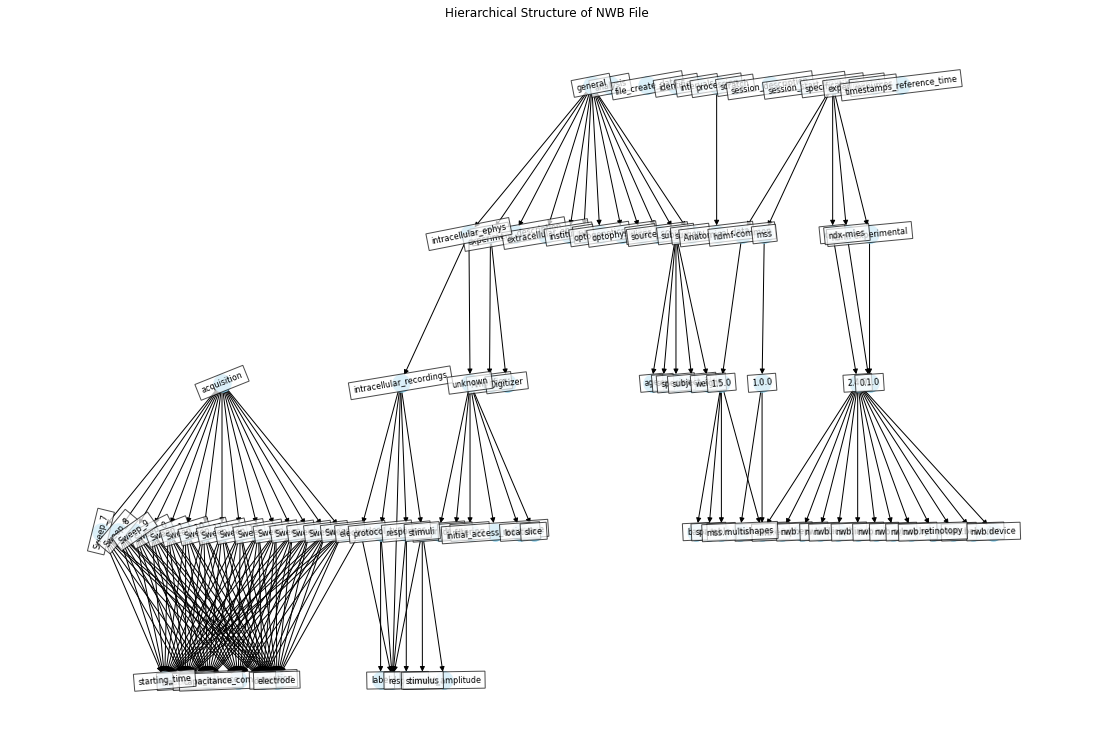

In [156]:
# Visualize the graph
draw_graph(graph)

In [19]:
# Open the NWB file
with h5py.File(file_path, 'r') as file:
    # Find the path and value of sampling rate or rate recursively starting from the root
    sampling_rate_info = find_sampling_rate(file)
    print(file['acquisition']['Sweep_0']['data'].attrs.keys())
    print(file['general']['intracellular_ephys']['intracellular_recordings']['protocol_type']['label'][:])
    print(file['acquisition'])
    


#I checked and this is the sampling rate for all recordings - 20kHz

<KeysViewHDF5 ['conversion', 'resolution', 'unit']>
[b'LP' b'LP' b'LP' b'LP' b'LP' b'LP' b'LP' b'LP' b'LP' b'LP' b'LP' b'LP'
 b'LP' b'LP' b'LP' b'SP' b'SP' b'SP' b'SP' b'SP' b'SP' b'SP' b'SP' b'SP'
 b'SP' b'SP' b'SP' b'SP' b'SP' b'SP' b'SP' b'SP' b'SP' b'SP' b'SP' b'SP'
 b'SP' b'SP' b'SP' b'SP' b'SP' b'SP' b'SP' b'SP' b'SP' b'SP' b'SP' b'SP'
 b'SP' b'SP' b'SP' b'SP' b'SP' b'SP' b'SP']
<HDF5 group "/acquisition" (55 members)>


### Get the patch data and examine

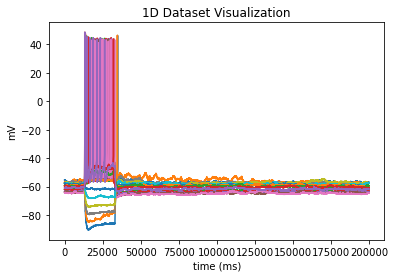

In [96]:
data = visualize_hdf5_data(file_path)


In [195]:
len(data)

15

In [221]:
data_test = data[5]

In [222]:
len(data_test)

200000

(0.0, 20000.0)

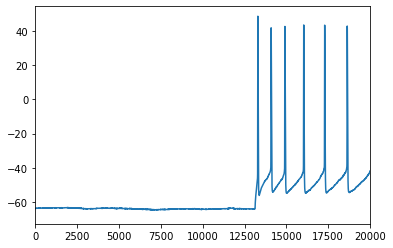

In [226]:
plt.plot(data_test)
plt.xlim(0,20000)




In [207]:
patch_fs = 20000
patch_times = np.arange(0, np.shape(data_test)[0]) / (patch_fs/1000) #


In [208]:
patch_times[-1] #10s/10000ms long recordings?

9999.95

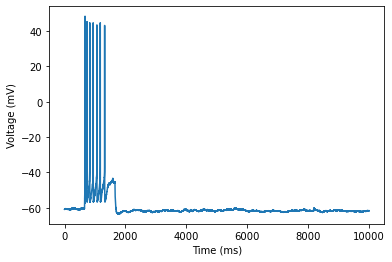

In [210]:
plt.plot(patch_times, data_test)
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.show()